In [1]:
import anndata as ad

In [2]:
import pandas as pd
import scipy.sparse as sp

In [3]:
from tqdm import tqdm

In [4]:
from genome_tools.data.anndata import read_zarr_backed
from genome_tools.data.extractors import FastaExtractor, TabixExtractor
from collections import defaultdict


In [5]:
import numpy as np

In [6]:
import anndata as ad
import pandas as pd
import numpy as np
import warnings
from tqdm import tqdm

from genome_tools import GenomicInterval, VariantInterval

In [7]:
from collections import defaultdict


In [8]:
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')
# adata

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings

In [9]:
non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/mbrannon/nonagg_merged_stats.parquet')

In [10]:
# non_aggregated_variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.all.parquet')
non_aggregated_variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,discordant,logit_group_es,full_group_std,z,signif_z,max_z,min_z,delta_es_q,discordance_score,category
0,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,False,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced
1,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,False,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced
2,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,False,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced
3,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,False,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced
4,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,False,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8076761,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,False,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced
8076762,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,False,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced
8076763,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,False,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced
8076764,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,False,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced


In [11]:
non_aggregated_variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id',
       'indiv_id', 'variant_id', 'group_id_cavs', 'group_es', 'group_es_std',
       'df', 't value', 'Pr(>|t|)', 'indivs_count', 'samples_count',
       'indiv_id_rand_var', 'chisq', 'chi_df', 'p_differential',
       'var_indiv_id', 'var_group_id', 'var_residuals', 'full_variance',
       'differential_fdr', 'cell_selective', 'n_groups', 'group_es_var',
       'mean_group_mse', 'min_pval_cavs', 'es_combined', 'min_fdr_overall',
       'overall_imbalanced', 'logit_es_combined', 'group_pval', 'fdr_group',
       'signif_es', 'signif_max_es', 'signi

In [12]:
non_aggregated_variants['variant_id'] = non_aggregated_variants['#chr'] + ":" + non_aggregated_variants['end'].astype(str) + ':' + non_aggregated_variants['ref'] + ':' + non_aggregated_variants['alt']
non_aggregated_variants['total_counts'] = non_aggregated_variants['ref_counts'] + non_aggregated_variants['alt_counts']

In [13]:
variants = non_aggregated_variants.query('coverage >= 35')

In [14]:
variants

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_group_es,full_group_std,z,signif_z,max_z,min_z,delta_es_q,discordance_score,category,total_counts
0,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,35
1,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
2,chr1,817185,817186,rs3094315,G,A,26,29,AG80823,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,55
3,chr1,817185,817186,rs3094315,G,A,33,24,AG70842,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,57
4,chr1,817185,817186,rs3094315,G,A,43,36,AG80260,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8076761,chr9,138217445,138217446,rs11562371,C,T,19,21,AG80066,0.370349,...,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,40
8076762,chr9,138217445,138217446,rs11562371,C,T,21,24,AG96533,0.370349,...,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,45
8076763,chr9,138217445,138217446,rs11562371,C,T,22,29,AG80065,0.370349,...,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,51
8076764,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,0.547406,0.313591,0.303583,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,39


In [37]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
indiv_id_mapping

,ln_number,ds_number,tc_number,core_annotation,extended_annotation,core_ontology_term,sample_type,system,subsystem,organ,...,total_cutcounts_file,cutcounts_tabix,SPOT1_score,SPOT3_score,total_fastq_reads,nuclear_reads,alignment_quality,nuclear_dup_rate,indiv_id,snps_file
sample_id,,,,,,,,,,,,,,,,,,,,,
AG10028,LN45952,DS58903,TC2653,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3182,0.074446,52520104,43150608,0.821602,0.090581,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10029,LN45951,DS58898,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3060,0.057275,54654080,44625318,0.816505,0.097833,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10031,LN45947,DS58779,TC2652,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3236,0.084240,62032686,48761214,0.786057,0.121074,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10032,LN45945,DS58765,TC2650,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3407,0.092941,65021458,51644128,0.794263,0.117462,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG10033,LN45944,DS58761,TC2649,Myeloid,CML,K562,Cell line,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3458,0.099725,62713902,50214894,0.800698,0.109526,INDIV_0002,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AG70923,LN26979,DS28156,TC4770,Myeloid,Monocyte,CD14+ monocyte,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2507,0.088885,21458764,14001510,0.652484,0.322671,NaN,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG72731,LN54316,DS70424,TC8000,Fetal life support,Fetal life support,Placenta,Primary cells/tissues,Reproductive,NaN,Placenta,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.5123,0.316107,205268193,168995390,0.823291,0.329474,INDIV_0433,/net/seq/data2/projects/sabramov/ENCODE4/dnase...
AG4026,LN33516,DS40210,TC5870,Colon,Colon,Transverse colon,Primary cells/tissues,Digestive,NaN,Colon,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.2153,0.123919,217560462,110999900,0.510203,0.332484,INDIV_0015,/net/seq/data2/projects/sabramov/ENCODE4/dnase...


In [27]:
variants = pd.read_parquet('/net/seq/data2/projects/mbrannon/nonagg_filtered_variants.parquet')

In [29]:
variants['variant_id'] = variants['#chr'] + ":" + variants['end'].astype(str) + ':' + variants['ref'] + ':' + variants['alt']


In [30]:
variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id',
       'indiv_id', 'variant_id', 'group_id_cavs', 'group_es', 'group_es_std',
       'df', 't value', 'Pr(>|t|)', 'indivs_count', 'samples_count',
       'indiv_id_rand_var', 'chisq', 'chi_df', 'p_differential',
       'var_indiv_id', 'var_group_id', 'var_residuals', 'full_variance',
       'differential_fdr', 'cell_selective', 'n_groups', 'group_es_var',
       'mean_group_mse', 'min_pval_cavs', 'es_combined', 'min_fdr_overall',
       'overall_imbalanced', 'logit_es_combined', 'group_pval', 'fdr_group',
       'signif_es', 'signif_max_es', 'signi

In [31]:
# var_df = variants_filtered.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]
var_df = variants.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 
                                                                      'ref_counts', 'alt_counts','sample_id', 'AAF', 'RAF','BAD',
                                                                      'SNP_count','w', 'es','logit_es','FDR_sample','inverse_mse', 
                                                                      'group_id','group_es', 'group_es_std','p_differential',
                                                                      'var_indiv_id', 'var_group_id','cell_selective', 'n_groups', 'group_es_var',
                                                                      'overall_imbalanced', 'logit_es_combined', 'group_pval', 'fdr_group',
                                                                      'signif_es', 'signif_max_es', 'signif_min_es', 'significant_group',
                                                                      'has_significant_group', 'concordant', 'discordant', 'logit_group_es',
                                                                      'full_group_std', 'z', 'signif_z', 'max_z', 'min_z', 'delta_es_q',
                                                                      'discordance_score', 'category', 'total_counts']]
                                                                      

In [32]:
var_df

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_group_es,full_group_std,z,signif_z,max_z,min_z,delta_es_q,discordance_score,category,total_counts
variant_id,,,,,,,,,,,,,,,,,,,,,
chr1:804904:C:T,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,35
chr1:817186:G:A,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr1:817237:C:A,chr1,817236,817237,rs149886465,C,A,28,8,AG80304,0.035081,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr1:817341:A:G,chr1,817340,817341,rs3131972,A,G,101,132,AG70842,0.665607,...,-0.757480,0.342293,-0.380761,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,233
chr1:817375:T:C,chr1,817374,817375,rs1417671147,T,C,26,97,AG79956,0.000048,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr9:138155803:G:A,chr9,138155802,138155803,rs147604762,G,A,31,14,AG93012,0.207585,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,45
chr9:138155904:T:G,chr9,138155903,138155904,rs9410084,T,G,19,17,AG92979,0.713892,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr9:138155977:G:T,chr9,138155976,138155977,rs12683077,G,T,24,13,AG72764,0.136850,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,37


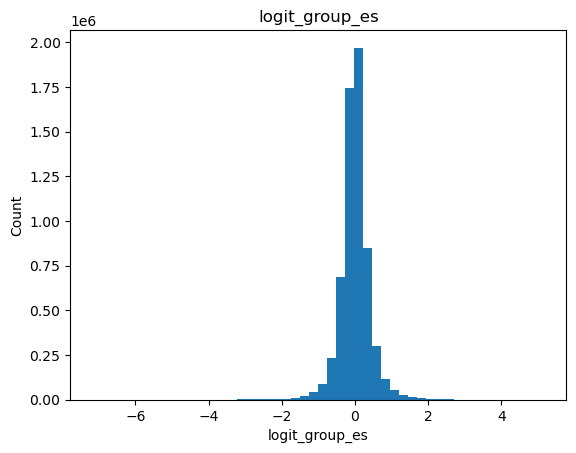

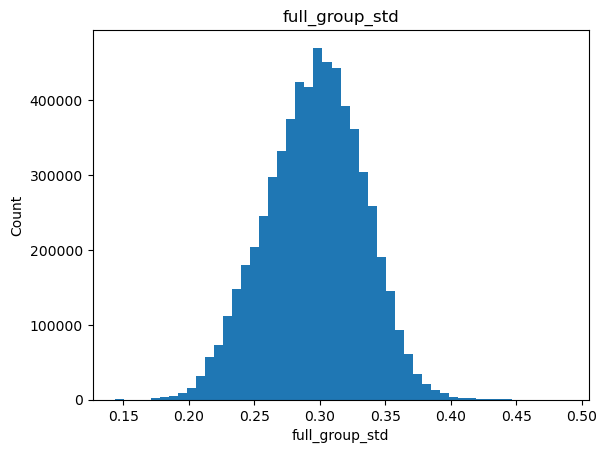

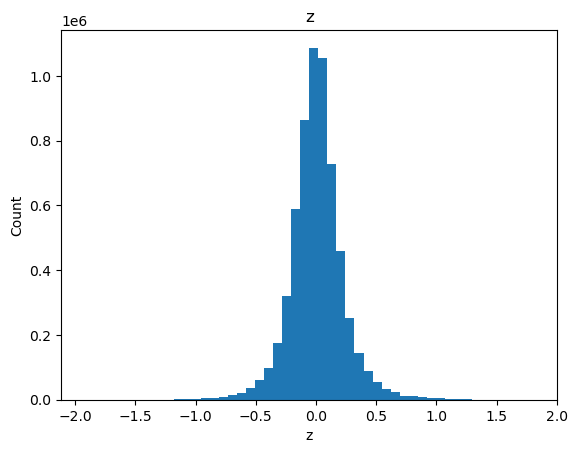

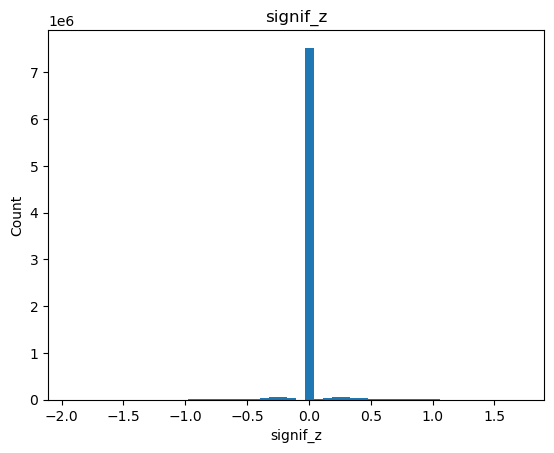

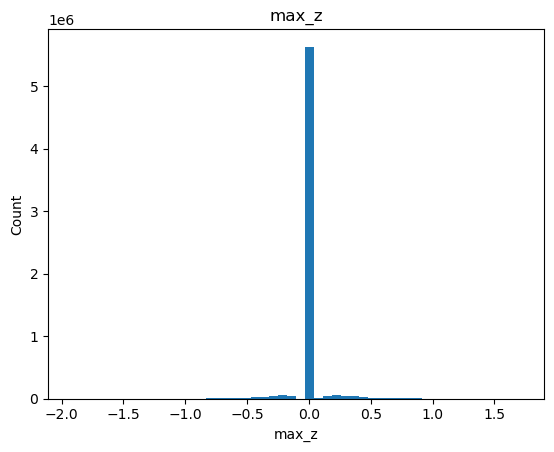

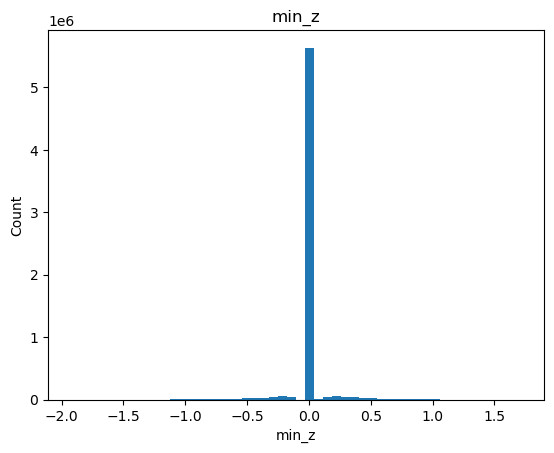

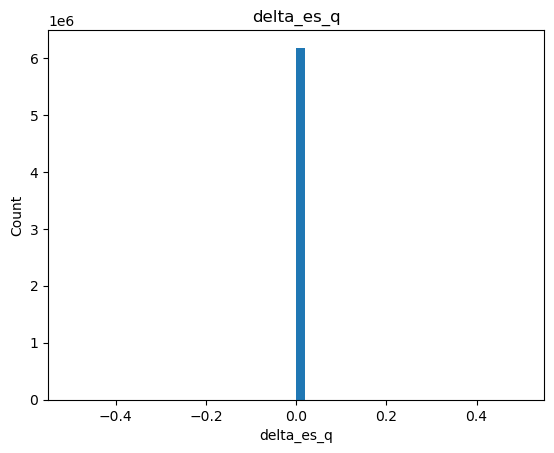

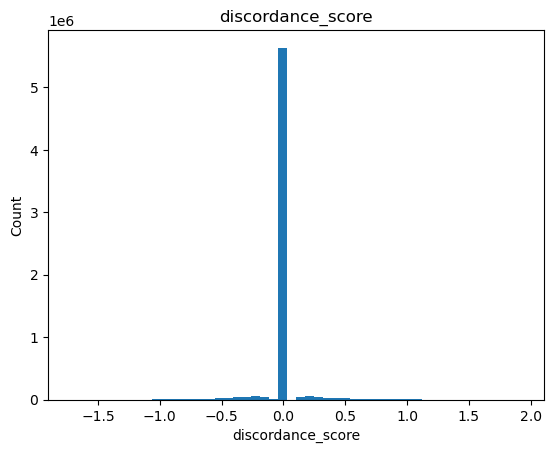

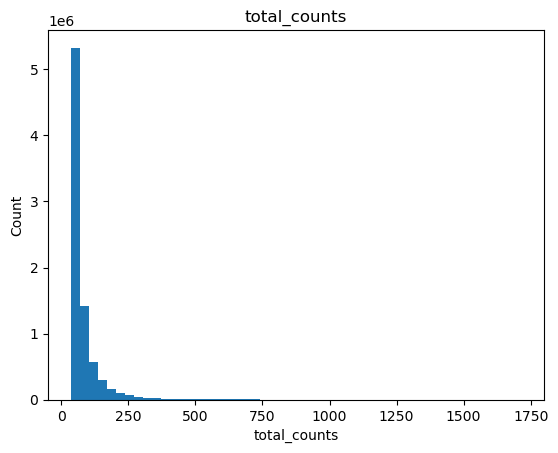

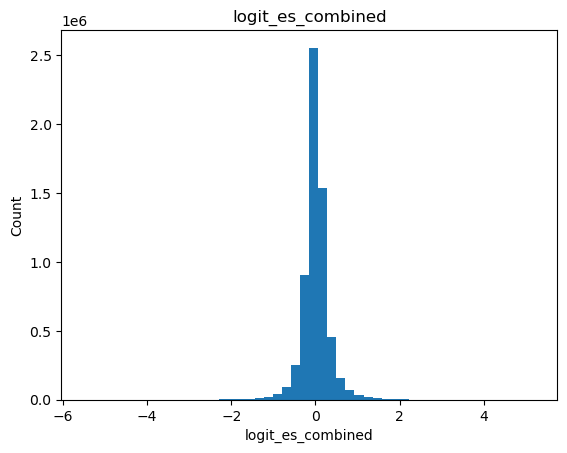

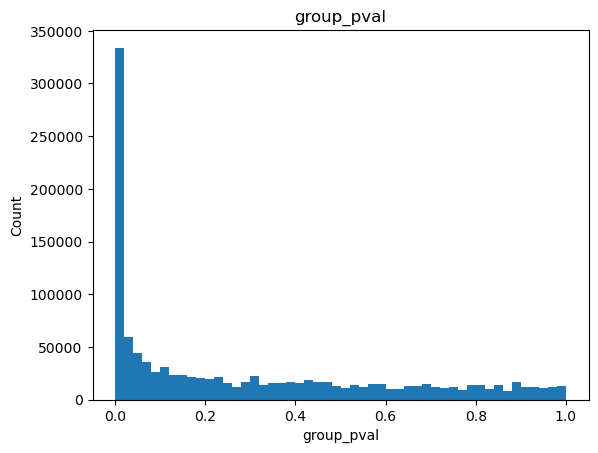

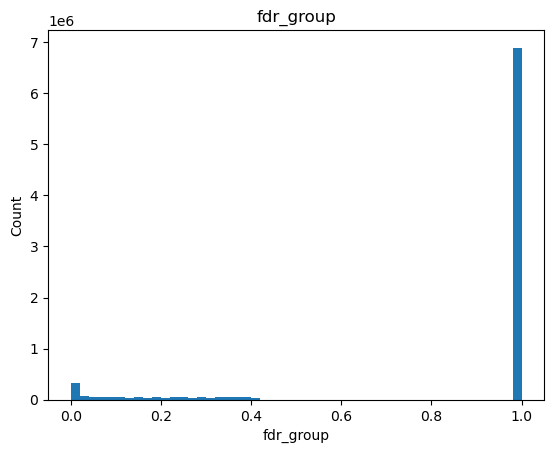

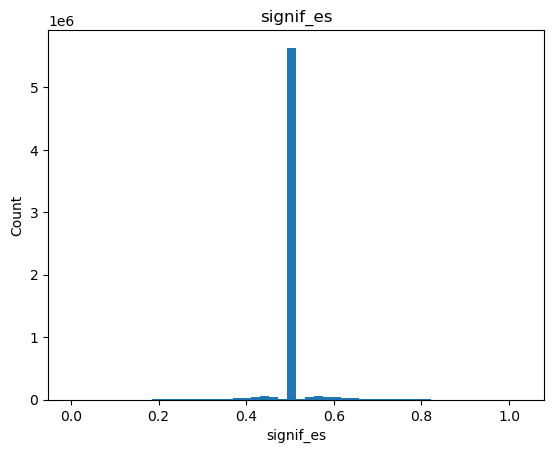

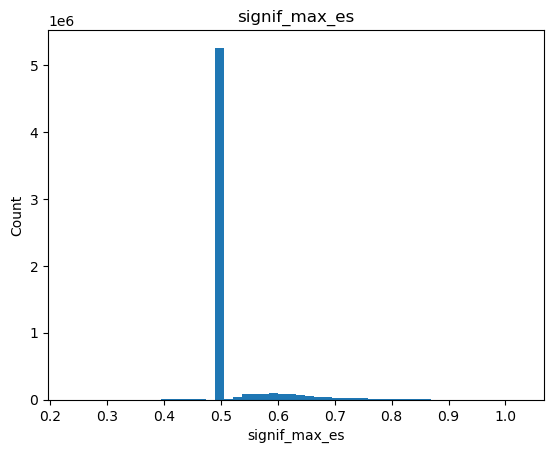

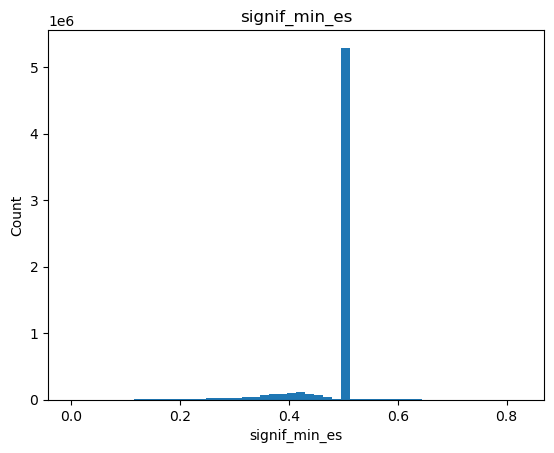

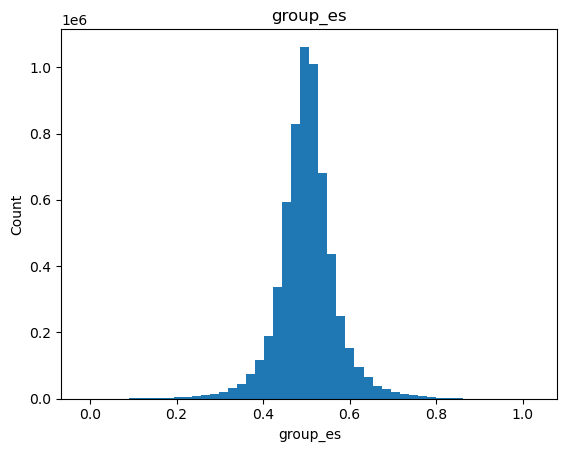

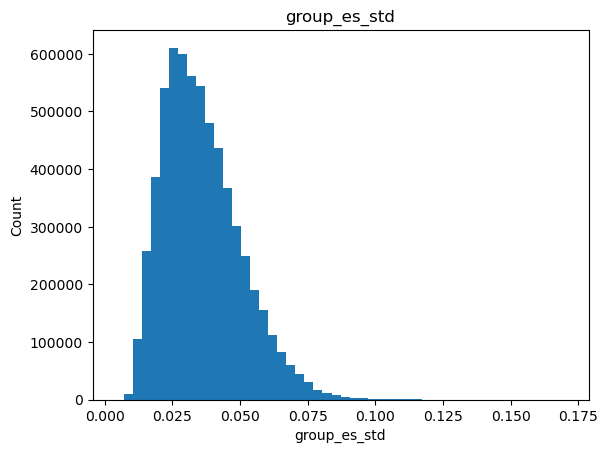

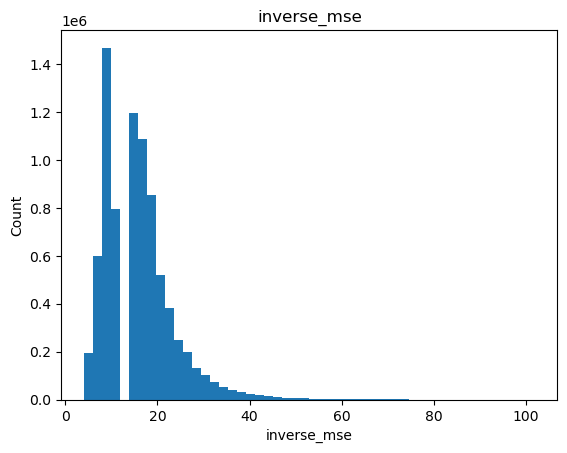

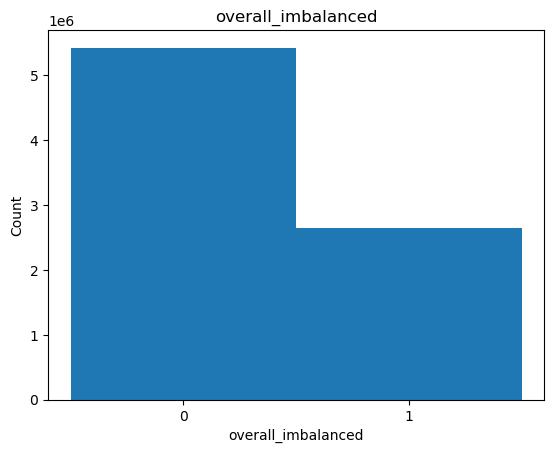

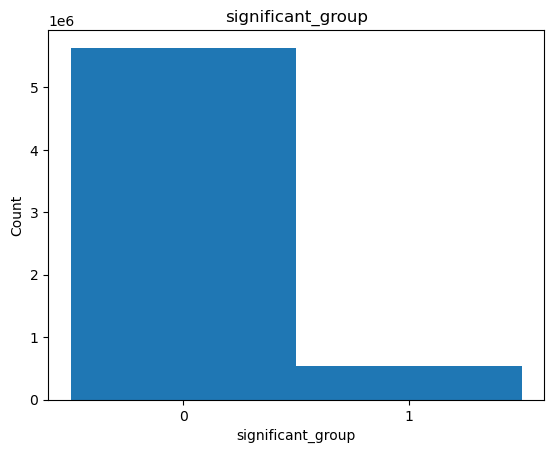

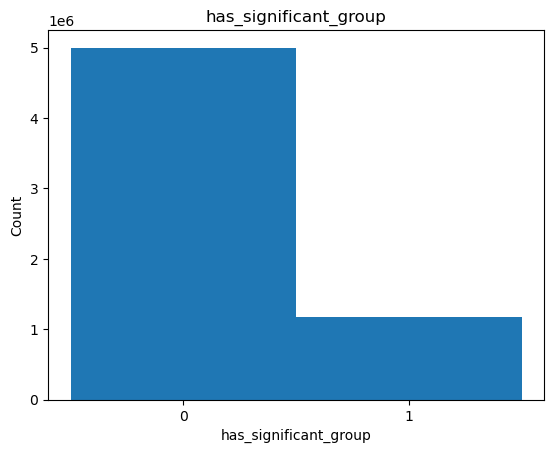

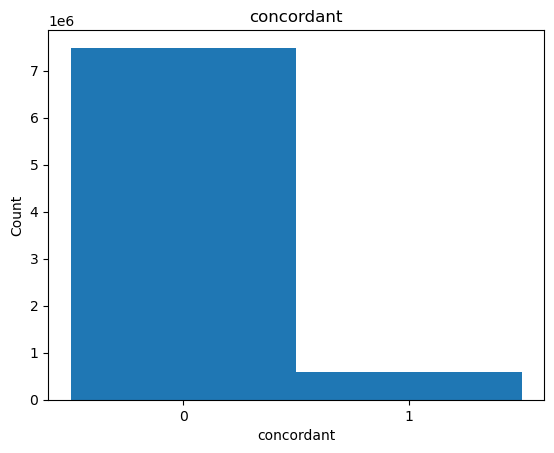

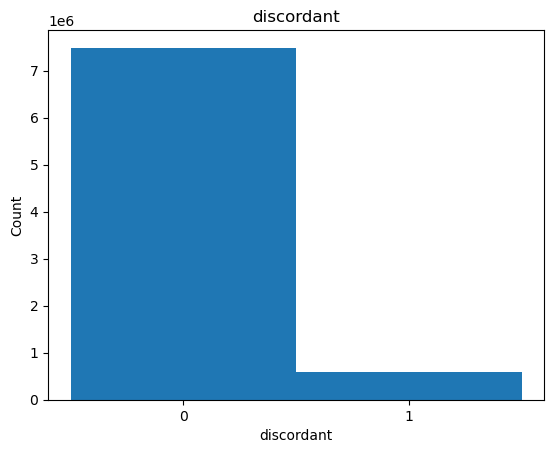

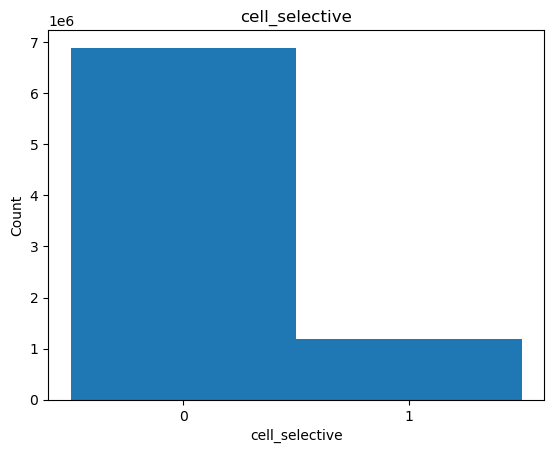

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Columns you asked for
numeric_cols = [
    "logit_group_es",
    "full_group_std",
    "z",
    "signif_z",
    "max_z",
    "min_z",
    "delta_es_q",
    "discordance_score",
    "total_counts",
    "logit_es_combined",
    "group_pval",
    "fdr_group",
    "signif_es",
    "signif_max_es",
    "signif_min_es",
    "group_es",
    "group_es_std",
    "inverse_mse",
]

bool_cols = [
    "overall_imbalanced",
    "significant_group",
    "has_significant_group",
    "concordant",
    "discordant",
    "cell_selective",
]

# --------------------
# Numeric histograms
# --------------------
for col in numeric_cols:
    if col not in var_df.columns:
        print(f"Skipping missing column: {col}")
        continue

    data = var_df[col].dropna()
    if data.empty:
        continue

    plt.figure()
    plt.hist(data, bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# --------------------
# Boolean histograms
# --------------------
for col in bool_cols:
    if col not in var_df.columns:
        print(f"Skipping missing column: {col}")
        continue

    data = var_df[col].dropna().astype(int)

    plt.figure()
    plt.hist(data, bins=[-0.5, 0.5, 1.5])
    plt.xticks([0, 1])
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [33]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757921
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [34]:
var_df

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,logit_group_es,full_group_std,z,signif_z,max_z,min_z,delta_es_q,discordance_score,category,total_counts
variant_id,,,,,,,,,,,,,,,,,,,,,
chr1:804904:C:T,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,35
chr1:817186:G:A,chr1,817185,817186,rs3094315,G,A,23,13,AG80733,0.706382,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr1:817237:C:A,chr1,817236,817237,rs149886465,C,A,28,8,AG80304,0.035081,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr1:817341:A:G,chr1,817340,817341,rs3131972,A,G,101,132,AG70842,0.665607,...,-0.757480,0.342293,-0.380761,0.0,0.0,0.0,0.0,-0.0,not_imbalanced,233
chr1:817375:T:C,chr1,817374,817375,rs1417671147,T,C,26,97,AG79956,0.000048,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr9:138155803:G:A,chr9,138155802,138155803,rs147604762,G,A,31,14,AG93012,0.207585,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,45
chr9:138155904:T:G,chr9,138155903,138155904,rs9410084,T,G,19,17,AG92979,0.713892,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,36
chr9:138155977:G:T,chr9,138155976,138155977,rs12683077,G,T,24,13,AG72764,0.136850,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,not_imbalanced,37


In [35]:
row_idx = train_var_adata.obs_names.get_indexer(variants["sample_id"])

# Map variant_id -> col index
col_idx = train_var_adata.var_names.get_indexer(variants["variant_id"])

for column in tqdm(['ref_counts', 'total_counts', 'BAD', 'logit_es', 'FDR_sample']):
    data = sp.coo_matrix(
        (variants[column], (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[column] = data


100%|██████████| 5/5 [00:00<00:00,  5.87it/s]


In [38]:
indiv_id_mapping['indiv_id']

sample_id
AG10028           NaN
AG10029           NaN
AG10031    INDIV_0002
AG10032    INDIV_0002
AG10033    INDIV_0002
              ...    
AG70923           NaN
AG72731    INDIV_0433
AG4026     INDIV_0015
AG4009     INDIV_0018
AG80141    INDIV_0363
Name: indiv_id, Length: 3480, dtype: object

In [39]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [40]:
sampled_val = pd.Series(train_var_adata.obs_names).sample(50).values
validation_chroms = ['chr9', 'chr22']

In [41]:
train_var_adata.uns['epoch_names'] = ['epoch_1']
train_var_adata.uns['n_epochs'] = 1
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]
train_var_adata.obsm['split_data'] = np.where(train_var_adata.obs_names.isin(sampled_val), 'val', 'train')
train_var_adata.varm['split_data'] = np.where(train_var_adata.var['#chr'].isin(validation_chroms), 'val', 'train')
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757921
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [42]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [43]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757921
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [44]:
bool_cols = [
    'significant_group',
    'has_significant_group',
    'concordant',
    'discordant',
    'cell_selective',
    'overall_imbalanced'
]

for c in bool_cols:
    if c in train_var_adata.var.columns:
        train_var_adata.var[c] = (
            train_var_adata.var[c]
            .fillna(False)
            .astype(bool)
        )


/tmp/slurm.9481044/ipykernel_2121782/492257043.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/slurm.9481044/ipykernel_2121782/492257043.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [45]:
train_var_adata.write_h5ad('/net/seq/data2/projects/mbrannon/variant_train_adata_wfdr_wmorestats_checkgeno.h5ad')

In [46]:
#take that anndata and split into 3 epochs
variant_file = '/net/seq/data2/projects/mbrannon/variant_train_adata_wfdr_wmorestats_checkgeno.h5ad'

In [47]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm


adata = ad.read_h5ad(variant_file)
n_rows, n_cols = adata.shape
print("Loaded AnnData:", adata.shape)


Loaded AnnData: (4159, 757921)


In [48]:
# ==================================================
# Build epoch indices (memory-efficient, real variants only)
# ==================================================
def build_epoch_indices_filtered(adata, epoch, seed=42):
    rng = np.random.default_rng(seed)

    # Source layers (all from epoch_1)
    layer_logit = adata.layers["logit_es.epoch_1"].tocoo()
    layer_ref   = adata.layers["ref_counts.epoch_1"].tocoo()
    layer_total = adata.layers["total_counts.epoch_1"].tocoo()
    layer_fdr = adata.layers["FDR_sample.epoch_1"].tocoo()

    # Compute alt and passed filter
    alt_data = layer_total.data - layer_ref.data
    passed_read_count = (layer_total.data > 20) & (layer_ref.data > 0) & (alt_data > 0)
    sig_if = (layer_fdr.data < 0.1) & (np.abs(layer_logit.data) < 6)
    neg_fdr = layer_fdr.data > 0.5
    # --------------------
    # Positives: |logit| < 6
    # --------------------
    pos_mask = passed_read_count & sig_if
    pos_rows = layer_logit.row[pos_mask]
    pos_cols = layer_logit.col[pos_mask]

    # --------------------
    # Negatives: |logit| < 0.1 (or whatever you want)
    # --------------------
    neg_mask = passed_read_count & neg_fdr
    neg_rows = layer_logit.row[neg_mask]
    neg_cols = layer_logit.col[neg_mask]

    # --------------------
    # Balance positives/negatives
    # --------------------
    n_pos = len(pos_rows)
    n_neg = len(neg_rows)
    print(f'n_pos {n_pos}')
    print(f'n_neg {n_neg}')
    if n_neg < n_pos:
        # downsample positives, no
        print('downsampling')
        keep_pos_idx = rng.choice(n_pos, size=n_neg, replace=False)
        pos_rows = pos_rows[keep_pos_idx]
        pos_cols = pos_cols[keep_pos_idx]
        n_pos = n_neg
    else:
        # downsample negatives
        keep_neg_idx = rng.choice(n_neg, size=n_pos, replace=False)
        neg_rows = neg_rows[keep_neg_idx]
        neg_cols = neg_cols[keep_neg_idx]
        n_neg = n_pos

    # --------------------
    # Combine indices to keep
    # --------------------
    keep_rows = np.concatenate([pos_rows, neg_rows])
    keep_cols = np.concatenate([pos_cols, neg_cols])

    print(f"{epoch}: {n_pos} positives, {n_neg} negatives, total {len(keep_rows)}")
    return pos_rows, pos_cols, neg_rows, neg_cols, keep_rows, keep_cols

# ==================================================
# Build new sparse AnnData with multiple epochs
# ==================================================
def build_epoch_anndata_sparse_filtered(adata, epochs=("epoch_1", "epoch_2", "epoch_3")):
    new = ad.AnnData(
        X=None,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm,
        varm=adata.varm,
        uns={"epoch_names": list(epochs)},
    )

    epoch_indices = {}

    for i, epoch in enumerate(tqdm(epochs, desc="Epochs")):
        pos_r, pos_c, neg_r, neg_c, keep_r, keep_c = build_epoch_indices_filtered(
            adata, epoch, seed=100 + i
        )
        epoch_indices[epoch] = {
            "pos": (pos_r, pos_c),
            "neg": (neg_r, neg_c),
            "keep": (keep_r, keep_c)
        }

        # Build layers
        for key in tqdm(["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"],
                        desc=f"Building layers for {epoch}", leave=False):
            src_layer = adata.layers[f"{key}.epoch_1"].tocoo()
            # Build a dict mapping nonzero positions
            data_dict = {(r, c): v for r, c, v in zip(src_layer.row, src_layer.col, src_layer.data)}

            # Fill values for kept indices, zero if absent
            layer_data = np.array([data_dict.get((r, c), 0) for r, c in zip(keep_r, keep_c)],
                                  dtype=src_layer.data.dtype)
            new.layers[f"{key}.{epoch}"] = sp.csr_matrix((layer_data, (keep_r, keep_c)), shape=adata.shape)
        gc.collect()

    return new, epoch_indices

# ==================================================
# Build epochs
# ==================================================
epochs = ["epoch_1", "epoch_2", "epoch_3"]
epoch_adata, epoch_indices = build_epoch_anndata_sparse_filtered(adata, epochs=epochs)

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

n_pos 275877
n_neg 7297735
epoch_1: 275877 positives, 275877 negatives, total 551754



Epochs:  33%|███▎      | 1/3 [00:23<00:47, 23.53s/it]                     

n_pos 275877
n_neg 7297735
epoch_2: 275877 positives, 275877 negatives, total 551754



Epochs:  67%|██████▋   | 2/3 [00:47<00:23, 23.69s/it]                     

n_pos 275877
n_neg 7297735
epoch_3: 275877 positives, 275877 negatives, total 551754



Epochs: 100%|██████████| 3/3 [01:11<00:00, 23.82s/it]                     


In [49]:
#check spread

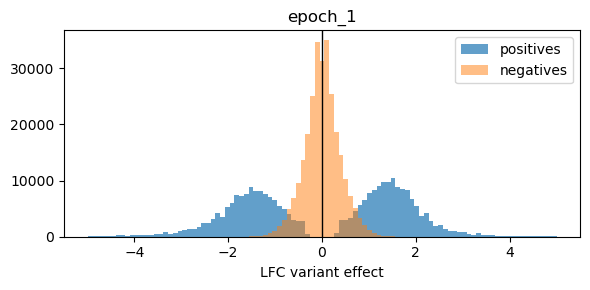

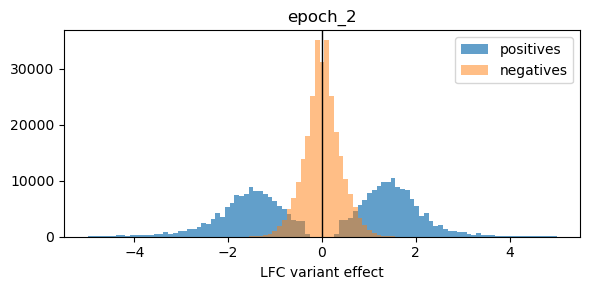

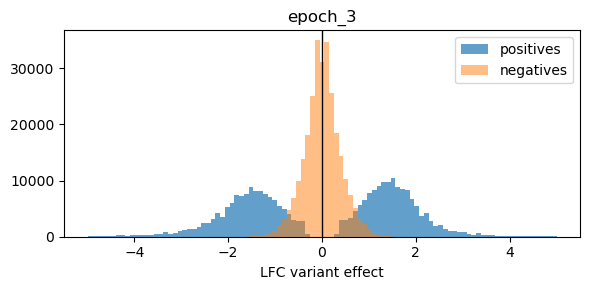

In [50]:
# ==================================================
# Sanity check histograms (match pandas)
# ==================================================
bins = np.linspace(-5, 5, 100)
for epoch, idx_dict in epoch_indices.items():
    logit = epoch_adata.layers[f"logit_es.{epoch}"]

    pos_rows, pos_cols = idx_dict["pos"]
    neg_rows, neg_cols = idx_dict["neg"]

    pos_vals = logit[pos_rows, pos_cols].A1
    neg_vals = logit[neg_rows, neg_cols].A1

    plt.figure(figsize=(6, 3))
    plt.hist(pos_vals, bins=bins, alpha=0.7, label="positives")
    plt.hist(neg_vals, bins=bins, alpha=0.5, label="negatives")
    plt.axvline(0, color="black", lw=1)
    plt.title(epoch)
    plt.xlabel("LFC variant effect")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [51]:
#bounds check
# ==================================================
print("\nRunning sanity checks...")
assert "epoch_names" in epoch_adata.uns
for epoch in epoch_adata.uns["epoch_names"]:
    for base in ["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"]:
        layer = f"{base}.{epoch}"
        assert layer in epoch_adata.layers, f"Missing {layer}"
        assert epoch_adata.layers[layer].shape == epoch_adata.shape
print("✔ All epoch layers present")
print("✔ Shapes consistent")
print("✔ Ready for training")


Running sanity checks...
✔ All epoch layers present
✔ Shapes consistent
✔ Ready for training


In [52]:
# ==================================================
# Save
# ==================================================
out_file = "/net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3_morestats_checkgeno.h5ad"
epoch_adata.write_h5ad(out_file, compression="gzip")
print("Saved:", out_file)

Saved: /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3_morestats_checkgeno.h5ad


In [ ]:
#then run in scripts elim ambig

srun --mem=200G python scripts/elim_ambig.py \
    --input_h5 /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3.h5ad \
    --output_h5 /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_epochs_balanced_noambig_epoch3_jitter40.h5ad \
    --fasta /net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
    --genotype /net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz
    --jitter 40


In [ ]:
#then train 

In [8]:
!cp /net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/legnet_embed.new_cluster.one_cycle_LR.yaml legnet_embed_dhs.yaml

cp: cannot open '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/legnet_embed.new_cluster.one_cycle_LR.yaml' for reading: Permission denied


In [ ]:
'/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/check_last_epoch=2.ckpt'
/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/legnet_embed.new_cluster.one_cycle_LR.yaml

In [ ]:
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3_morestats.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/net/seq/data2/projects/mbrannon/all_phased.no_ambiguous.sorted.bed.gz \
/net/seq/data2/projects/mbrannon/variant_model_test \
--config /home/mbrannon/.local/src/vinson/train/variant/basset_embed.new_cluster.one_cycle_LR.yaml \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--nodelist hpcg04-heavy --debug

In [71]:
from vinson.datasets.variant import VariantEmbedDataset
import anndata as ad
from vinson.utils.data_formatting import extract_variant_data_from_anndata
import torch
from torch.utils.data import DataLoader


adata =  ad.read_h5ad('/net/seq/data2/projects/mbrannon/vinson/variant_train_adata_balanced_epochs3_morestats.h5ad')
full_data = extract_variant_data_from_anndata(adata, "epoch_1")
genotype_file = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz'
fasta_file = '/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa'
dataset = VariantEmbedDataset(
    data=full_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file
)
loader = DataLoader(dataset, batch_size=128, shuffle=False)


In [72]:
batch = next(iter(loader))
X_ref, X_alt, X_embed = batch["ohe_seq_ref"], batch["ohe_seq_alt"], batch["embed"]
trunk_out_size = (X_ref.shape[1] + X_alt.shape[1] + X_embed.shape[1])
print("Set head.n_inputs to:", trunk_out_size)


Set head.n_inputs to: 645
